In [ ]:
from typing import TypedDict

class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    total_inr: float

In [3]:
# Example object of PortfolioState

my_obj:PortfolioState = {
    # 'amount_usd': 1.0,
    'amount_usd':None,
    'total_usd': 2.0,
    'total_inr': 3.0
}


In [14]:
def calc_total(state: PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def calc_inr(state: PortfolioState) -> PortfolioState:
    state['total_inr'] = state['total_usd'] * 90.0
    return state

In [ ]:
from langgraph.graph import StateGraph,START,END

builder = StateGraph(PortfolioState)

builder.add_node("calc_total_node", calc_total)
builder.add_node("calc_inr_node", calc_inr)

builder.add_edge(START, "calc_total_node")
builder.add_edge("calc_total_node", "calc_inr_node")
builder.add_edge("calc_inr_node", END)

In [16]:
graph = builder.compile()

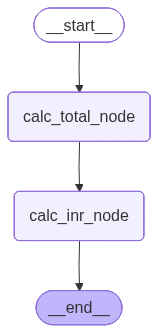

In [17]:
from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))  # type: ignore

In [18]:
graph.invoke({"amount_usd":100.0})

{'amount_usd': 100.0, 'total_usd': 108.0, 'total_inr': 9720.0}